In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Análise de lucratividade por subcategoria dentro de Furniture
df = pd.read_csv("sample_-_superstore.csv")
furniture_df = df[df["Category"] == "Furniture"]
lucro_por_sub = furniture_df.groupby('Sub-Category')['Profit'].sum().sort_values()

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_20408\2658375331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lucro_por_sub.index, y=lucro_por_sub.values, palette='RdYlGn')


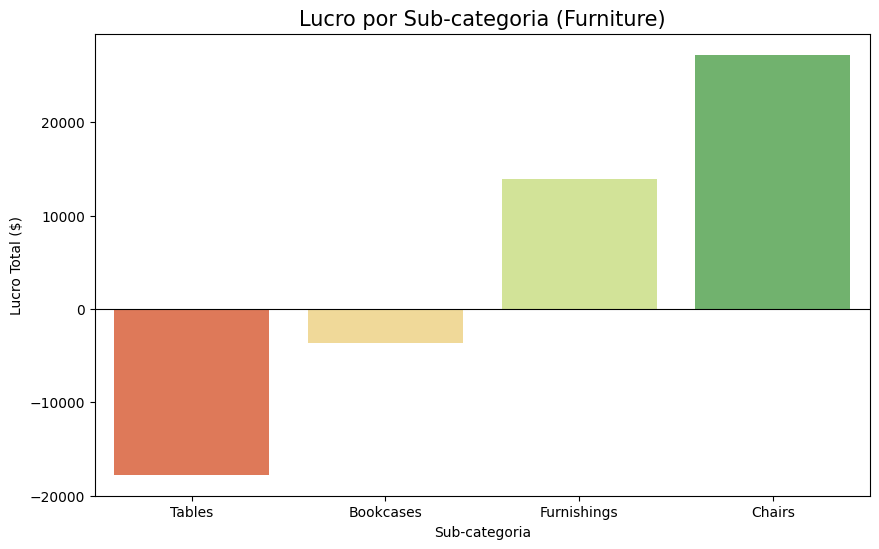

In [ ]:
# Gráfico de lucro total por subcategoria
# Escala de cor: vermelho = prejuízo, verde = lucro

plt.figure(figsize=(10, 6))
sns.barplot(x=lucro_por_sub.index, y=lucro_por_sub.values, palette='RdYlGn')

plt.title('Lucro por Sub-categoria (Furniture)', fontsize=15)
plt.ylabel('Lucro Total ($)')
plt.xlabel('Sub-categoria')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

In [ ]:
# Correlação de Pearson entre desconto e lucro

from scipy import stats
r, p = stats.pearsonr(furniture_df['Discount'], furniture_df['Profit'])
print(f"Correlação: {r:.3f} | p-valor: {p:.4f}")

Correlação: -0.478 | p-valor: 0.0000


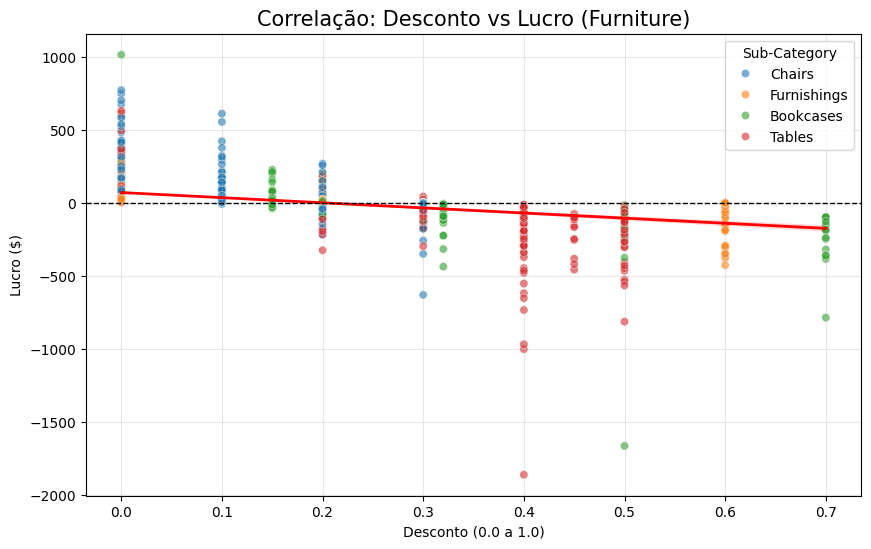

In [ ]:
# Dispersão com reta de regressão linear — quanto maior o desconto, menor o lucro

plt.figure(figsize=(10, 6))

sns.scatterplot(data=furniture_df, x='Discount', y='Profit', hue='Sub-Category', alpha=0.6)

sns.regplot(data=furniture_df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Correlação: Desconto vs Lucro (Furniture)', fontsize=15)
plt.xlabel('Desconto (0.0 a 1.0)')
plt.ylabel('Lucro ($)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.show()